#### Import libraries

In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load dataset

In [122]:
df = pd.read_csv("../data/retail_sales.csv")
df.head()

,date,store_id,item_id,sales,price,promo,weekday,month
0,2019-01-01,store_1,item_1,41,21.30,0,1,1
1,2019-01-02,store_1,item_1,53,21.30,0,2,1
2,2019-01-03,store_1,item_1,39,21.30,0,3,1
3,2019-01-04,store_1,item_1,35,21.30,0,4,1
4,2019-01-05,store_1,item_1,51,17.04,1,5,1


In [123]:
df.shape

(4565000, 8)

In [124]:
df.columns

Index(['date', 'store_id', 'item_id', 'sales', 'price', 'promo', 'weekday',
       'month'],
      dtype='object')

In [125]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4565000 entries, 0 to 4564999
Data columns (total 8 columns):
 #   Column    Dtype  
---  ------    -----  
 0   date      object 
 1   store_id  object 
 2   item_id   object 
 3   sales     int64  
 4   price     float64
 5   promo     int64  
 6   weekday   int64  
 7   month     int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 278.6+ MB


In [126]:
df.describe()

,sales,price,promo,weekday,month
count,4.565000e+06,4.565000e+06,4.565000e+06,4.565000e+06,4.565000e+06
mean,2.926466e+01,5.399323e+01,9.999869e-02,3.001643e+00,6.523549e+00
std,1.500996e+01,2.578461e+01,2.999983e-01,1.999315e+00,3.448534e+00
min,0.000000e+00,8.020000e+00,0.000000e+00,0.000000e+00,1.000000e+00
25%,1.800000e+01,3.197000e+01,0.000000e+00,1.000000e+00,4.000000e+00
50%,2.700000e+01,5.352000e+01,0.000000e+00,3.000000e+00,7.000000e+00
75%,3.800000e+01,7.536000e+01,0.000000e+00,5.000000e+00,1.000000e+01
max,1.390000e+02,9.999000e+01,1.000000e+00,6.000000e+00,1.200000e+01


In [127]:
df.isnull().sum()

date        0
store_id    0
item_id     0
sales       0
price       0
promo       0
weekday     0
month       0
dtype: int64

### Convert date column

In [128]:
df['date'] = pd.to_datetime(df['date'])

In [129]:
df = df.sort_values('date')

In [130]:
df.head()

,date,store_id,item_id,sales,price,promo,weekday,month
0,2019-01-01,store_1,item_1,41,21.30,0,1,1
483890,2019-01-01,store_6,item_16,27,78.57,0,1,1
3515050,2019-01-01,store_39,item_26,47,31.60,0,1,1
3516876,2019-01-01,store_39,item_27,34,17.33,0,1,1
3518702,2019-01-01,store_39,item_28,19,35.23,1,1,1


In [131]:
df.tail()

,date,store_id,item_id,sales,price,promo,weekday,month
3036637,2023-12-31,store_34,item_13,47,30.31,0,6,12
3034811,2023-12-31,store_34,item_12,19,74.23,0,6,12
3032985,2023-12-31,store_34,item_11,26,28.21,0,6,12
3045767,2023-12-31,store_34,item_18,42,34.27,0,6,12
4564999,2023-12-31,store_50,item_50,10,80.12,0,6,12


In [132]:
df.isnull().sum()

date        0
store_id    0
item_id     0
sales       0
price       0
promo       0
weekday     0
month       0
dtype: int64

### Initial Time Series Analysis

In [133]:
df['store_id'].nunique()
df['item_id'].nunique()

50

In [134]:
df['sales'].describe()

count    4.565000e+06
mean     2.926466e+01
std      1.500996e+01
min      0.000000e+00
25%      1.800000e+01
50%      2.700000e+01
75%      3.800000e+01
max      1.390000e+02
Name: sales, dtype: float64

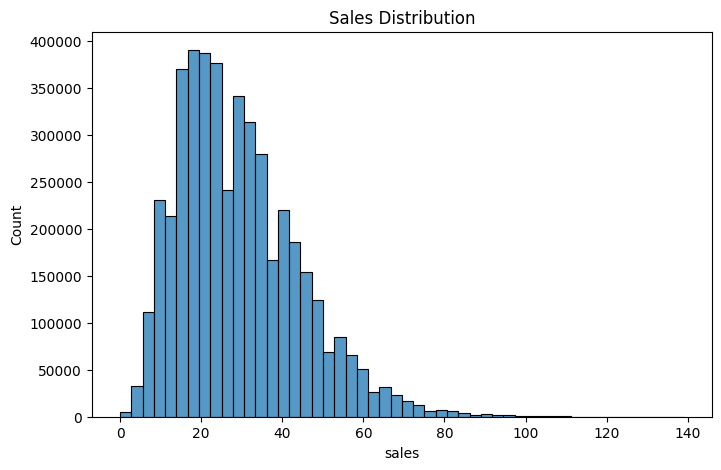

In [135]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['sales'], bins=50)
plt.title("Sales Distribution")
plt.show()

In [136]:
daily_sales = df.groupby('date')['sales'].sum().reset_index()

<Figure size 1400x600 with 0 Axes>

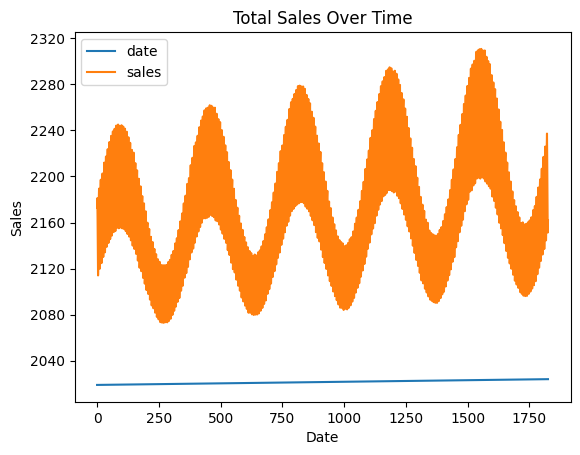

In [137]:
plt.figure(figsize=(14,6))
daily_sales.plot()
plt.title("Total Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

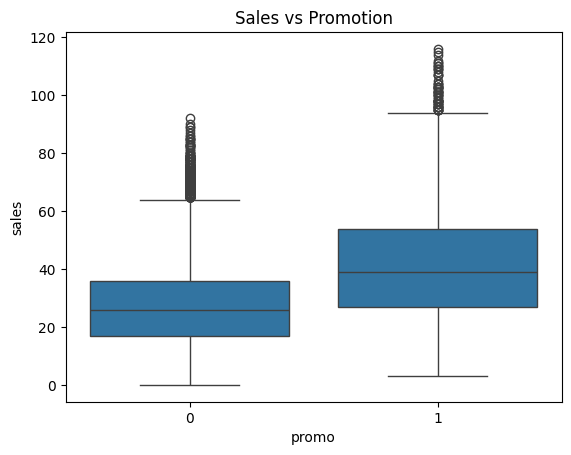

In [138]:
sns.boxplot(x='promo', y='sales', data=df.sample(50000))
plt.title("Sales vs Promotion")
plt.show()

### Stationarity test

In [139]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(daily_sales['sales'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -12.180033111487258
p-value: 1.3581993272102212e-22


In [140]:
daily_sales['sales_diff'] = daily_sales['sales'].diff()
daily_sales = daily_sales.dropna()

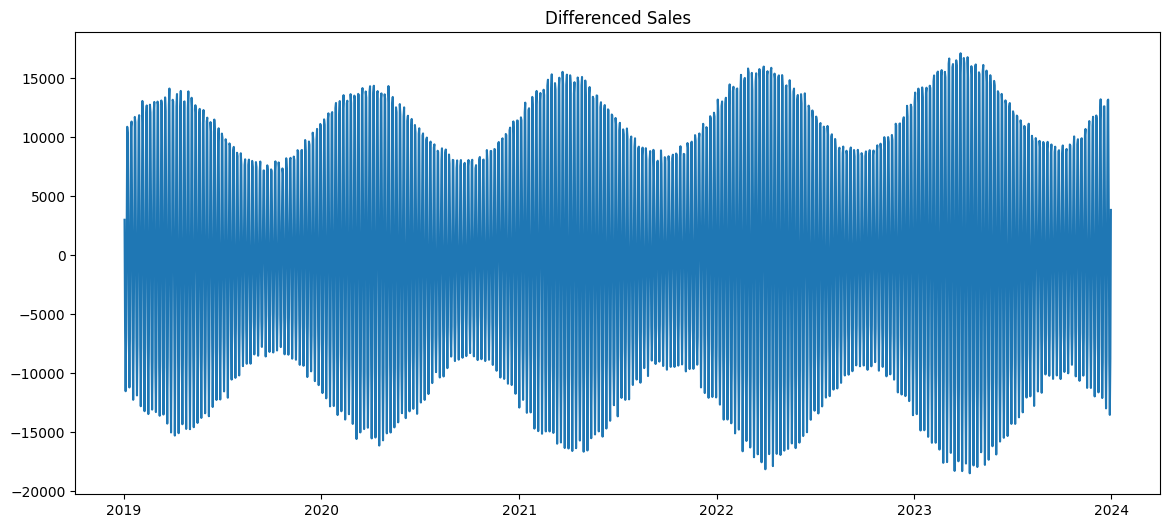

In [141]:
plt.figure(figsize=(14,6))
plt.plot(daily_sales['date'], daily_sales['sales_diff'])
plt.title("Differenced Sales")
plt.show()

### Baseline forecasting model

In [142]:
train_size = int(len(daily_sales) * 0.8)

train = daily_sales[:train_size]
test = daily_sales[train_size:]

In [143]:
print(len(train), len(test))

1460 365


In [144]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train['sales'], order=(5,0,0))
model_fit = model.fit()

c:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [145]:
forecast = model_fit.forecast(steps=len(test))

c:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


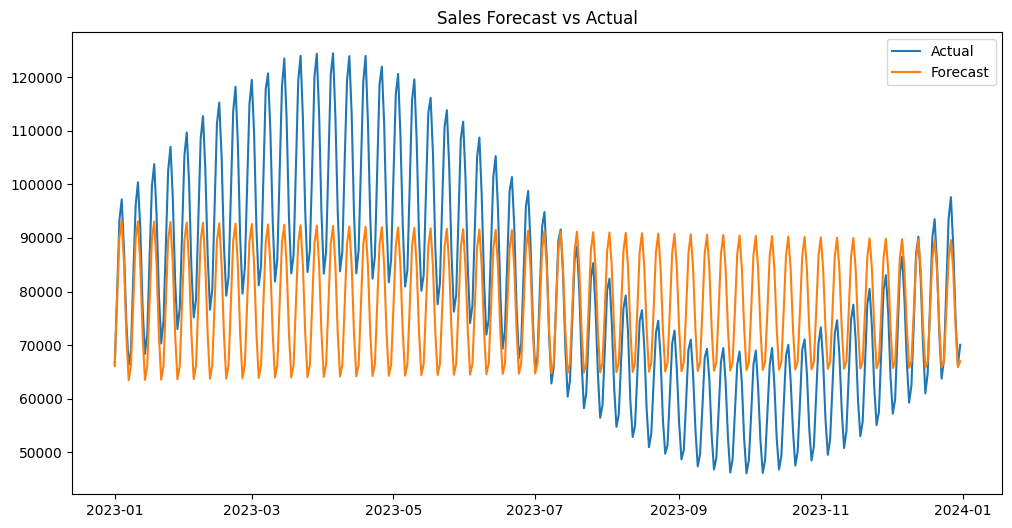

In [146]:
plt.figure(figsize=(12,6))

plt.plot(test['date'], test['sales'], label="Actual")
plt.plot(test['date'], forecast, label="Forecast")

plt.legend()
plt.title("Sales Forecast vs Actual")
plt.show()

In [147]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(test['sales'], forecast)

print("MAE:", mae)

MAE: 14607.962192913377


### Store-Item level forecasting

In [148]:
df['store_id'].unique()[:10]

array(['store_1', 'store_6', 'store_39', 'store_40', 'store_5',
       'store_38', 'store_41', 'store_42', 'store_4', 'store_35'],
      dtype=object)

In [149]:
df['item_id'].unique()[:10]

array(['item_1', 'item_16', 'item_26', 'item_27', 'item_28', 'item_15',
       'item_29', 'item_30', 'item_14', 'item_31'], dtype=object)

In [150]:
store = "store_1"
item = "item_1"

In [151]:
filtered_df = df[(df['store_id'] == "store_1") & (df['item_id'] == "item_1")]

In [152]:
filtered_df.head()

,date,store_id,item_id,sales,price,promo,weekday,month
0,2019-01-01,store_1,item_1,41,21.30,0,1,1
1,2019-01-02,store_1,item_1,53,21.30,0,2,1
2,2019-01-03,store_1,item_1,39,21.30,0,3,1
3,2019-01-04,store_1,item_1,35,21.30,0,4,1
4,2019-01-05,store_1,item_1,51,17.04,1,5,1


In [153]:
item_sales = filtered_df.groupby('date')['sales'].sum().reset_index()

In [154]:
item_sales.head()

,date,sales
0,2019-01-01,41
1,2019-01-02,53
2,2019-01-03,39
3,2019-01-04,35
4,2019-01-05,51


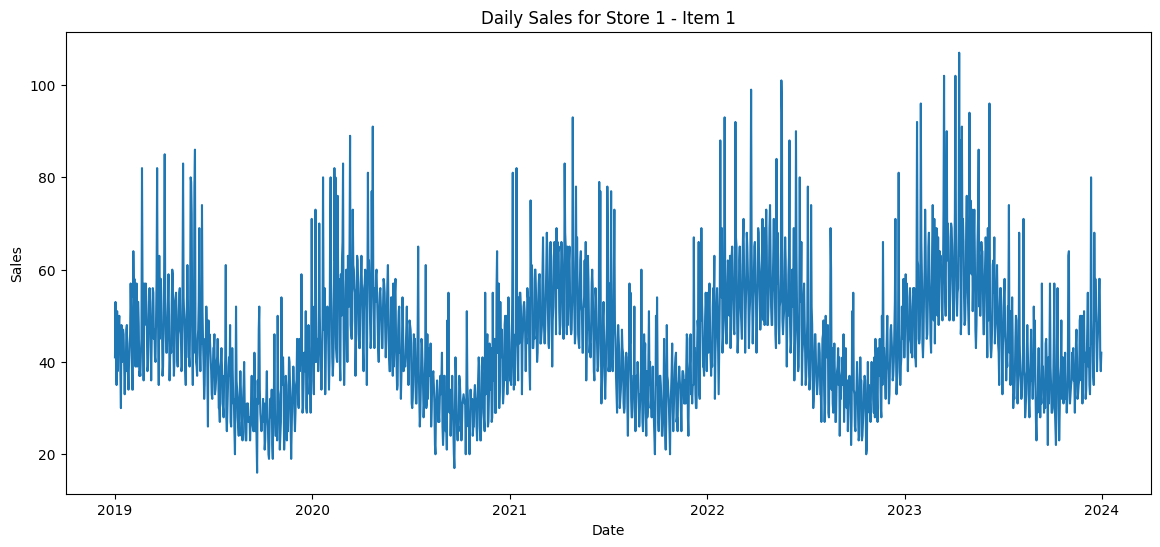

In [155]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(item_sales['date'], item_sales['sales'])

plt.title("Daily Sales for Store 1 - Item 1")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

### Prepare data for Prophet

In [156]:
prophet_df = item_sales.rename(columns={
    "date": "ds",
    "sales": "y"
})

In [157]:
prophet_df.head()

,ds,y
0,2019-01-01,41
1,2019-01-02,53
2,2019-01-03,39
3,2019-01-04,35
4,2019-01-05,51


### Train Prophet model

In [158]:
from prophet import Prophet

model = Prophet()

model.fit(prophet_df)

19:21:10 - cmdstanpy - INFO - Chain [1] start processing
19:21:13 - cmdstanpy - INFO - Chain [1] done processing


### Predict future sales

In [159]:
future = model.make_future_dataframe(periods=30)

forecast = model.predict(future)

### Visualize forecast

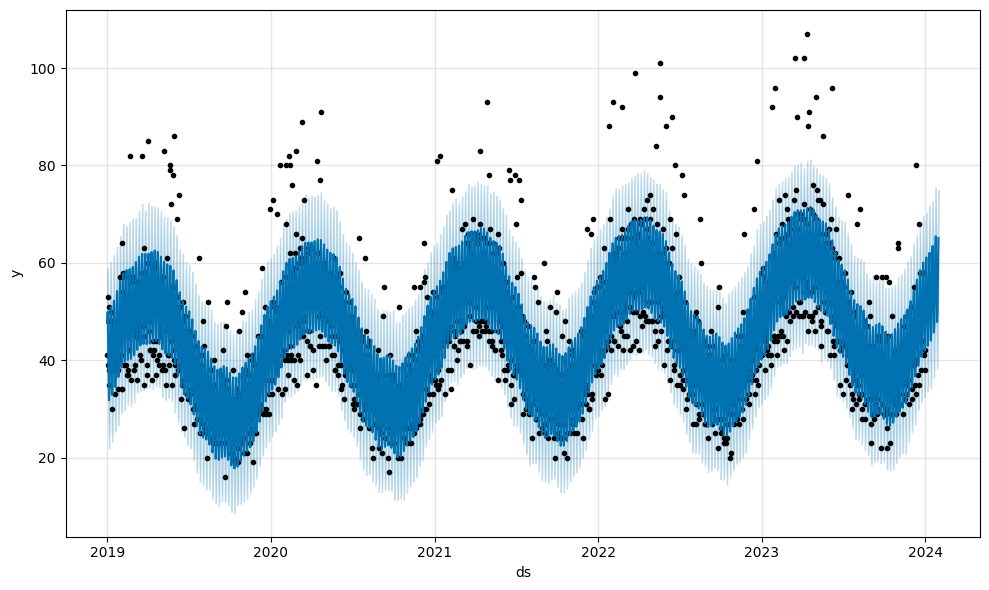

In [161]:
fig = model.plot(forecast)

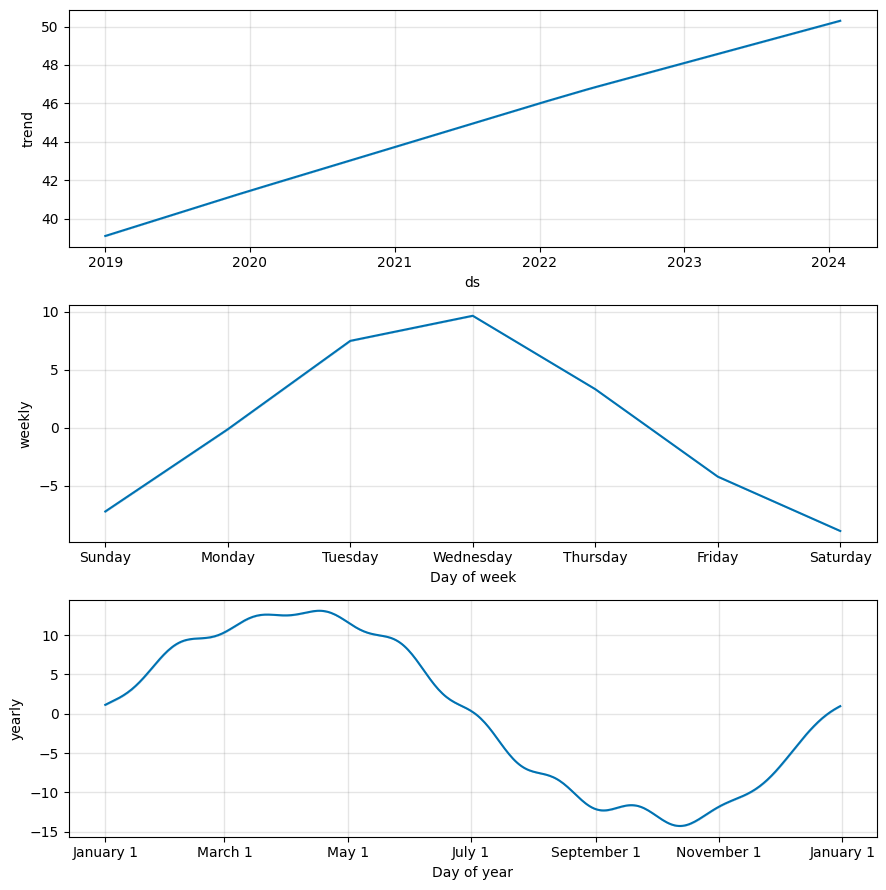

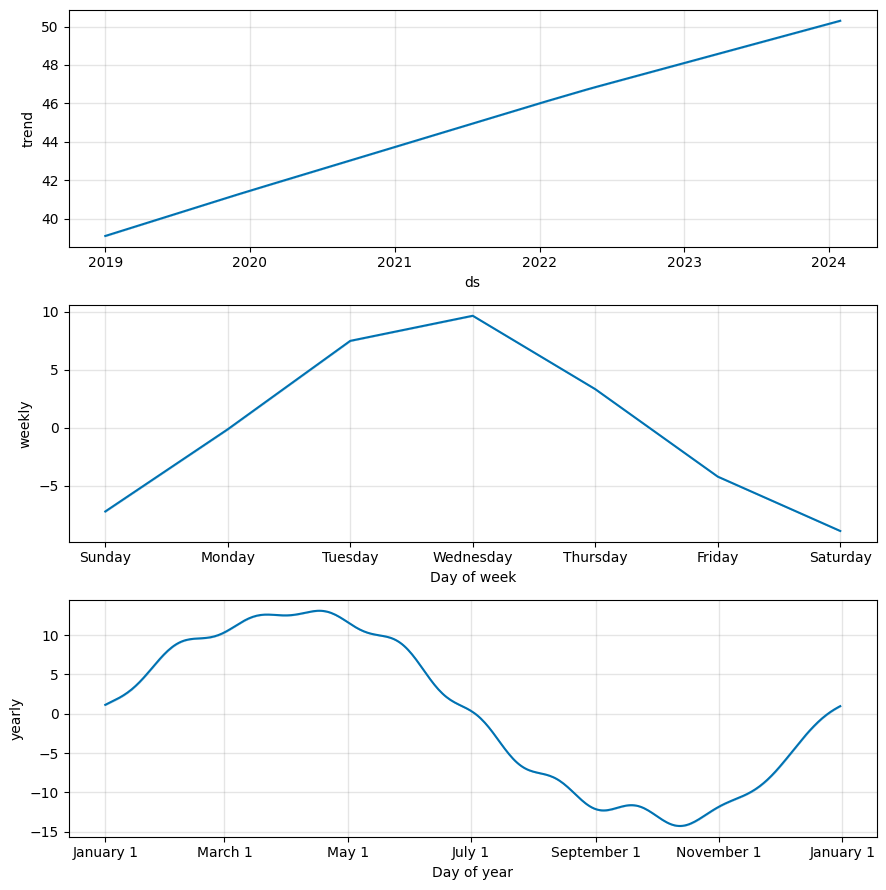

In [162]:
model.plot_components(forecast)

### Extracting the 30-Day Forecast Table

In [165]:
future_sales = forecast[['ds','yhat','yhat_lower','yhat_upper']].tail(30)
future_sales

,ds,yhat,yhat_lower,yhat_upper
1826,2024-01-01,51.037804,41.708806,60.766616
1827,2024-01-02,58.792691,49.348919,68.093301
1828,2024-01-03,61.087753,51.376826,70.287941
1829,2024-01-04,54.894465,45.606583,64.481192
1830,2024-01-05,47.486485,38.231672,57.178848
1831,2024-01-06,42.934464,33.574478,51.213294
1832,2024-01-07,44.749683,35.325049,54.080811
1833,2024-01-08,51.976195,42.640301,61.513232
1834,2024-01-09,59.742180,49.807909,68.821750
1835,2024-01-10,62.059861,53.201617,71.817015


In [166]:
future_sales.to_csv("future_30_day_sales_forecast.csv", index=False)

## Business Insights

* Sales show a clear seasonal pattern across the year.
* Weekly demand variation exists due to weekday shopping patterns.
* The Prophet model predicts stable demand for the next 30 days.
* Promotions and pricing may influence demand spikes.